# Интерактивный конспект: Свёрточные и полносвязные нейронные сети

Этот notebook — самодостаточный конспект по теме задания 11.1. Здесь демонстрируются ключевые техники работы с PyTorch: от простого `nn.Module` до обучения свёрточной сети на игрушечных данных.

**Содержание:**
1. Импорты и настройка
2. Простейший `nn.Module` с `nn.Parameter`
3. Визуализация функций активации
4. Ядра свёртки: blur, sharpen, edge detection
5. Расчёт размера feature map
6. Training loop на sklearn moons
7. Ручной backward vs autograd
8. Попробуй сам

## 1. Импорты и настройка

Фиксируем seed для воспроизводимости.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# Фиксируем сид для воспроизводимости
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f'PyTorch version: {torch.__version__}')

PyTorch version: 2.11.0


## 2. Простейший nn.Module с nn.Parameter

Реализуем линейный слой вручную — без использования `nn.Linear`. Это показывает, как `nn.Parameter` регистрирует обучаемые тензоры в модели.

**Ключевые моменты:**
- Наследуемся от `nn.Module`.
- В `__init__` вызываем `super().__init__()` (обязательно).
- Параметры оборачиваем в `nn.Parameter` — тогда они попадут в `model.parameters()`.
- В `forward` описываем прямой проход.

[Документация nn.Module](https://docs.pytorch.org/docs/stable/generated/torch.nn.Module.html)

In [2]:
class MyLinear(nn.Module):
    """Линейный слой вручную: y = x @ W + b."""

    def __init__(self, in_features, out_features):
        super().__init__()
        # nn.Parameter -> автоматическая регистрация в model.parameters()
        self.W = nn.Parameter(torch.randn(in_features, out_features) * 0.01)
        self.b = nn.Parameter(torch.zeros(out_features))

    def forward(self, x):
        return x @ self.W + self.b


# Создаём модель и смотрим на её параметры
model = MyLinear(in_features=3, out_features=2)
print('Параметры модели:')
for name, p in model.named_parameters():
    print(f'  {name}: shape={tuple(p.shape)}, requires_grad={p.requires_grad}')

# Прямой проход
x = torch.randn(4, 3)  # батч из 4 объектов с 3 признаками
out = model(x)
print(f'\nВход: {x.shape}, выход: {out.shape}')
print(f'Всего параметров: {sum(p.numel() for p in model.parameters())}')

Параметры модели:
  W: shape=(3, 2), requires_grad=True
  b: shape=(2,), requires_grad=True

Вход: torch.Size([4, 3]), выход: torch.Size([4, 2])
Всего параметров: 8


## 3. Визуализация функций активации

Сравним 5 популярных активаций на одном графике. Активации — это нелинейные функции, применяемые поэлементно к выходу линейного слоя. Без них композиция линейных слоёв остаётся линейной.

**Формулы:**
- Identity: $f(x) = x$
- ReLU: $f(x) = \max(0, x)$
- LeakyReLU: $f(x) = \max(0.01x, x)$
- ELU: $f(x) = x$ при $x > 0$, иначе $\alpha(e^x - 1)$
- Tanh: $f(x) = \tanh(x)$

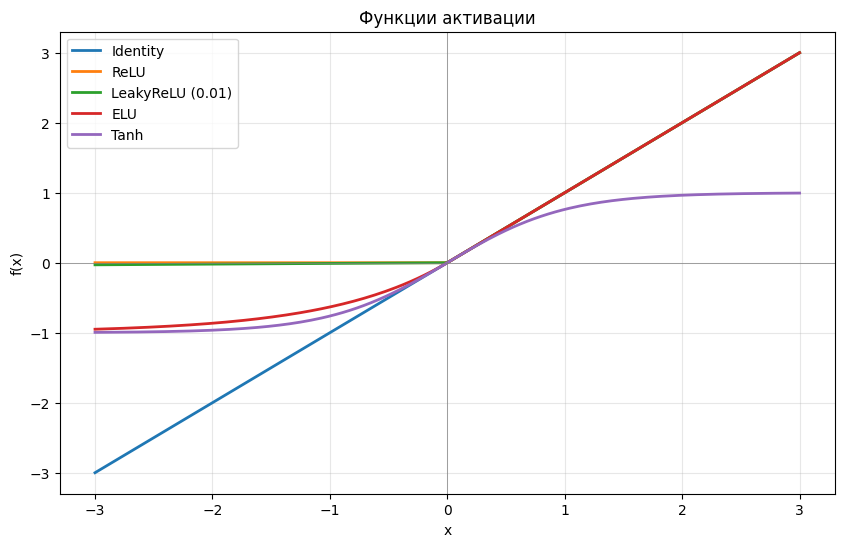

In [3]:
x = torch.linspace(-3, 3, 200)

activations = {
    'Identity': x,
    'ReLU': F.relu(x),
    'LeakyReLU (0.01)': F.leaky_relu(x, negative_slope=0.01),
    'ELU': F.elu(x),
    'Tanh': torch.tanh(x),
}

plt.figure(figsize=(10, 6))
for name, y in activations.items():
    plt.plot(x.numpy(), y.numpy(), label=name, linewidth=2)

plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.title('Функции активации')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 4. Ядра свёртки: blur, sharpen, edge detection

Свёртка применяет небольшое ядро (kernel) ко всем положениям изображения. Разные ядра извлекают разные признаки:

- **Тождественное** — не меняет изображение (центр=1, остальное=0)
- **Blur** — размытие (усреднение)
- **Sharpen** — увеличение резкости (усиление центра)
- **Edge detection** — выделение границ (Laplacian)

Применим эти ядра к синтетическому изображению с помощью `F.conv2d`.

[Документация F.conv2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.functional.conv2d.html)

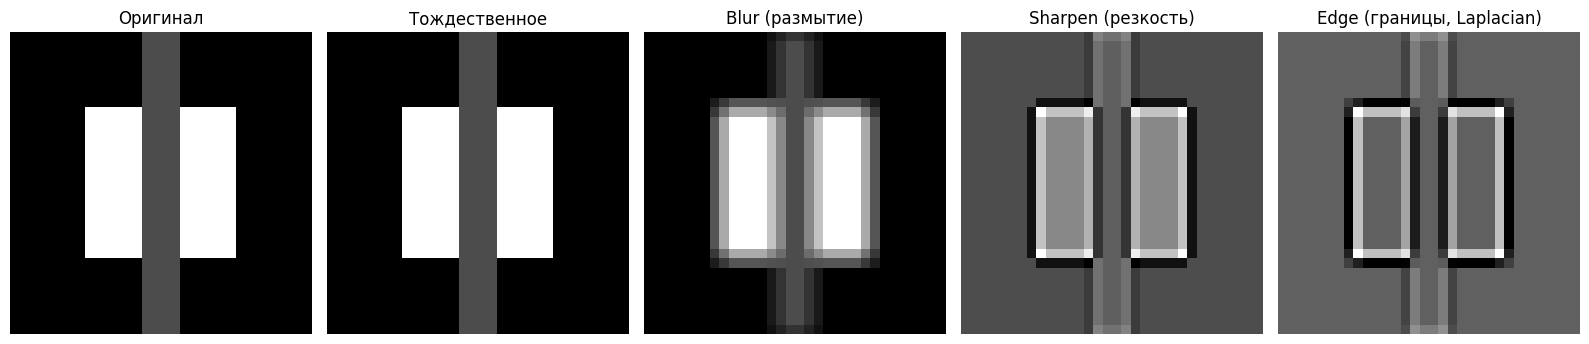

In [4]:
# Создаём простое синтетическое изображение 32x32: квадрат с полосой
img = np.zeros((32, 32), dtype=np.float32)
# Белый квадрат в центре
img[8:24, 8:24] = 1.0
# Тёмная вертикальная полоса
img[:, 14:18] = 0.3

# Добавляем батч и канал: [N=1, C=1, H, W]
img_t = torch.from_numpy(img).unsqueeze(0).unsqueeze(0)

# Определяем 4 ядра 3x3
kernels = {
    'Тождественное': [[0, 0, 0], [0, 1, 0], [0, 0, 0]],
    'Blur (размытие)': [[1/9]*3 for _ in range(3)],
    'Sharpen (резкость)': [[0, -1, 0], [-1, 5, -1], [0, -1, 0]],
    'Edge (границы, Laplacian)': [[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]],
}

fig, axes = plt.subplots(1, 5, figsize=(16, 4))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Оригинал')
axes[0].axis('off')

for idx, (name, k) in enumerate(kernels.items(), start=1):
    # Преобразуем ядро в тензор нужной формы: [out_c=1, in_c=1, 3, 3]
    kernel = torch.tensor(k, dtype=torch.float32).reshape(1, 1, 3, 3)
    # padding=1 сохраняет размер (32x32 -> 32x32)
    out = F.conv2d(img_t, kernel, padding=1)
    axes[idx].imshow(out.squeeze().numpy(), cmap='gray')
    axes[idx].set_title(name)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 5. Расчёт размера feature map

После свёртки и пулинга размер карты признаков меняется. Формула:

$$H_{out} = \left\lfloor \frac{H_{in} + 2p - k}{s} \right\rfloor + 1$$

где $p$ — padding, $k$ — размер ядра, $s$ — stride.

Разберём прохождение 28x28 MNIST-изображения через LeNet.

In [5]:
def conv_out_size(h_in, kernel, padding=0, stride=1):
    """Размер выходной feature map после свёртки или пулинга."""
    return (h_in + 2 * padding - kernel) // stride + 1

# Прохождение изображения через LeNet
print('Прохождение 28x28 изображения через LeNet:')
print('-' * 50)

h = 28
print(f'Вход:                    {h}x{h}, каналов: 1')

h = conv_out_size(h, kernel=3, padding=0, stride=1)
print(f'Conv2d(1->6, kernel=3):  {h}x{h}, каналов: 6')

h = conv_out_size(h, kernel=2, padding=0, stride=2)
print(f'MaxPool(2):              {h}x{h}, каналов: 6')

h = conv_out_size(h, kernel=3, padding=0, stride=1)
print(f'Conv2d(6->16, kernel=3): {h}x{h}, каналов: 16')

h = conv_out_size(h, kernel=2, padding=0, stride=2)
print(f'MaxPool(2):              {h}x{h}, каналов: 16')

flatten_size = 16 * h * h
print(f'Flatten:                 {flatten_size} признаков -> Linear(400, 120)')

Прохождение 28x28 изображения через LeNet:
--------------------------------------------------
Вход:                    28x28, каналов: 1
Conv2d(1->6, kernel=3):  26x26, каналов: 6
MaxPool(2):              13x13, каналов: 6
Conv2d(6->16, kernel=3): 11x11, каналов: 16
MaxPool(2):              5x5, каналов: 16
Flatten:                 400 признаков -> Linear(400, 120)


## 6. Training loop на sklearn moons

Обучим простую MLP на классическом игрушечном датасете `make_moons` (две полумесяцеобразные области). Это быстрый способ проверить, что pipeline обучения работает.

**Структура training loop:**
1. `optimizer.zero_grad()` — обнуляем накопленные градиенты
2. `logits = model(x)` — прямой проход
3. `loss = loss_fn(logits, y)` — считаем функцию потерь
4. `loss.backward()` — обратный проход (PyTorch autograd)
5. `optimizer.step()` — шаг оптимизатора

[Документация DataLoader](https://docs.pytorch.org/docs/stable/data.html)

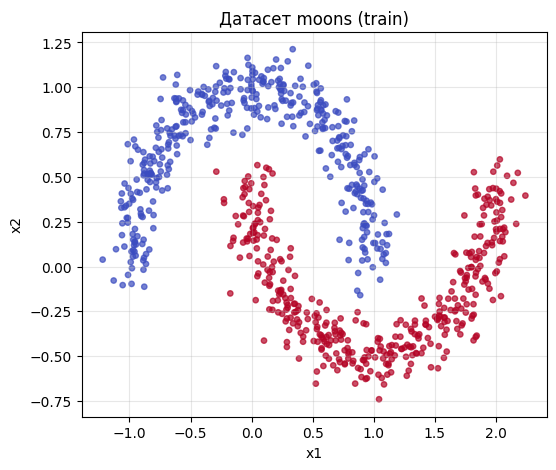

In [6]:
# Генерируем данные
X, y = make_moons(n_samples=1000, noise=0.1, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# numpy -> torch
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

# DataLoader
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=32, shuffle=False)

# Визуализация данных
plt.figure(figsize=(6, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', s=15, alpha=0.7)
plt.title('Датасет moons (train)')
plt.xlabel('x1'); plt.ylabel('x2')
plt.grid(alpha=0.3)
plt.show()

Финальный val accuracy: 1.0000
Финальный train loss:   0.0051


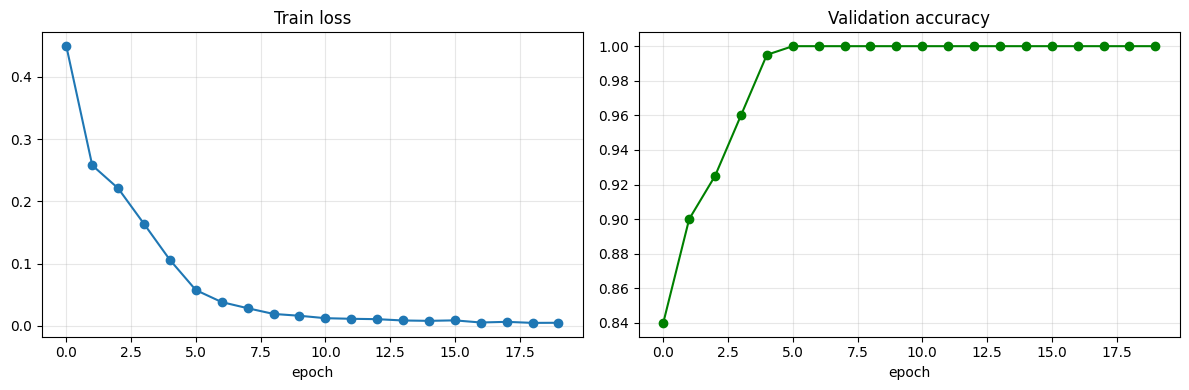

In [7]:
# Простая MLP: 2 -> 16 -> 16 -> 2
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 2),  # 2 класса
        )

    def forward(self, x):
        return self.net(x)


torch.manual_seed(42)
model = SimpleMLP()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

train_losses, val_accs = [], []

for epoch in range(20):
    # --- TRAIN ---
    model.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()        # 1. обнуляем градиенты
        logits = model(xb)           # 2. forward
        loss = loss_fn(logits, yb)   # 3. loss
        loss.backward()              # 4. backward (autograd)
        optimizer.step()             # 5. обновление весов
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(train_loader))

    # --- VALIDATION (режим inference) ---
    model.train(mode=False)          # переключаем в режим инференса
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model(xb).argmax(-1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    val_accs.append(correct / total)

print(f'Финальный val accuracy: {val_accs[-1]:.4f}')
print(f'Финальный train loss:   {train_losses[-1]:.4f}')

# Графики
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(train_losses, marker='o')
ax[0].set_title('Train loss'); ax[0].set_xlabel('epoch'); ax[0].grid(alpha=0.3)
ax[1].plot(val_accs, marker='o', color='green')
ax[1].set_title('Validation accuracy'); ax[1].set_xlabel('epoch'); ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Ручной backward vs autograd

Сравним вычисление градиента функции активации двумя способами:
- **Вручную**: используем аналитическую формулу производной
- **Через autograd**: PyTorch сам строит вычислительный граф и вычисляет градиент

Для ReLU: $f(x) = \max(0, x)$, производная $f'(x) = [x > 0]$.

Для Tanh: $f(x) = \tanh(x)$, производная $f'(x) = 1 - \tanh^2(x)$.

In [8]:
# Сравнение ручного и автоматического backward для ReLU и Tanh
x_test = torch.tensor([-2.0, -0.5, 0.0, 0.5, 2.0], requires_grad=True)

# --- ReLU ---
# Ручной backward: grad = 1 если x>0, иначе 0
manual_relu_grad = (x_test > 0).float()

# Autograd
y_relu = F.relu(x_test)
y_relu.sum().backward(retain_graph=True)  # сумма -> градиент = производная по каждому элементу
auto_relu_grad = x_test.grad.clone()
x_test.grad.zero_()

print('=== ReLU ===')
print(f'x:            {x_test.detach().tolist()}')
print(f'Ручной grad:  {manual_relu_grad.tolist()}')
print(f'Autograd:     {auto_relu_grad.tolist()}')
print(f'Совпадают:    {torch.allclose(manual_relu_grad, auto_relu_grad)}')

# --- Tanh ---
# Ручной backward: grad = 1 - tanh^2(x)
manual_tanh_grad = 1 - torch.tanh(x_test.detach()) ** 2

# Autograd
y_tanh = torch.tanh(x_test)
y_tanh.sum().backward()
auto_tanh_grad = x_test.grad.clone()

print('\n=== Tanh ===')
print(f'x:            {x_test.detach().tolist()}')
print(f'Ручной grad:  {[round(v, 4) for v in manual_tanh_grad.tolist()]}')
print(f'Autograd:     {[round(v, 4) for v in auto_tanh_grad.tolist()]}')
print(f'Совпадают:    {torch.allclose(manual_tanh_grad, auto_tanh_grad, atol=1e-6)}')

=== ReLU ===
x:            [-2.0, -0.5, 0.0, 0.5, 2.0]
Ручной grad:  [0.0, 0.0, 0.0, 1.0, 1.0]
Autograd:     [0.0, 0.0, 0.0, 1.0, 1.0]
Совпадают:    True

=== Tanh ===
x:            [-2.0, -0.5, 0.0, 0.5, 2.0]
Ручной grad:  [0.0707, 0.7864, 1.0, 0.7864, 0.0707]
Autograd:     [0.0707, 0.7864, 1.0, 0.7864, 0.0707]
Совпадают:    True


## 8. Попробуй сам

Задания для самостоятельной практики. Попробуй решить их, не подглядывая в ответы!

### Задача 8.1: Увеличь глубину MLP
Возьми модель `SimpleMLP` из раздела 6 и добавь ещё один скрытый слой. Посмотри, как изменится accuracy.

**Подсказка:** добавь `nn.Linear(16, 16)` + `nn.ReLU()` в `nn.Sequential`.

### Задача 8.2: Реализуй Sobel-фильтр
Создай ядро для выделения вертикальных границ (оператор Собеля) и примени его к изображению из раздела 4.

**Подсказка:** ядро `[[-1,0,1],[-2,0,2],[-1,0,1]]`.

### Задача 8.3: Посчитай количество параметров свёртки
Сколько параметров в `Conv2d(in_channels=3, out_channels=16, kernel_size=3)`?

**Подсказка:** формула — `in_c * out_c * k * k + out_c` (включая bias).

### Задача 8.4: Реализуй LeakyReLU вручную
Напиши класс `MyLeakyReLU(nn.Module)` с `forward` и ручным `backward`. Сравни с `F.leaky_relu`.

**Подсказка:** forward — `torch.where(x > 0, x, alpha * x)`, backward — `torch.where(x > 0, 1.0, alpha)`.

In [9]:
# --- Решение 8.3: подсчёт параметров свёртки ---
conv = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3)
n_params = sum(p.numel() for p in conv.parameters())
print(f'Параметров в Conv2d(3, 16, 3): {n_params}')
print(f'  Формула: 3 * 16 * 3 * 3 + 16 = {3*16*3*3 + 16}')

# --- Решение 8.4: свой LeakyReLU ---
class MyLeakyReLU(nn.Module):
    def __init__(self, alpha=0.01):
        super().__init__()
        self.alpha = alpha

    def forward(self, x):
        return torch.where(x > 0, x, self.alpha * x)

    def backward(self, x):
        return torch.where(x > 0, torch.ones_like(x), self.alpha * torch.ones_like(x))

# Проверка
my_lrelu = MyLeakyReLU(alpha=0.01)
x_chk = torch.tensor([-2.0, -0.5, 0.0, 0.5, 2.0])
print(f'\nMyLeakyReLU forward:  {my_lrelu.forward(x_chk).tolist()}')
print(f'F.leaky_relu forward: {F.leaky_relu(x_chk, 0.01).tolist()}')
print(f'Совпадают: {torch.allclose(my_lrelu.forward(x_chk), F.leaky_relu(x_chk, 0.01))}')

Параметров в Conv2d(3, 16, 3): 448
  Формула: 3 * 16 * 3 * 3 + 16 = 448

MyLeakyReLU forward:  [-0.019999999552965164, -0.004999999888241291, 0.0, 0.5, 2.0]
F.leaky_relu forward: [-0.019999999552965164, -0.004999999888241291, 0.0, 0.5, 2.0]
Совпадают: True


## Итоги

Мы разобрали:
1. Как устроен `nn.Module` и `nn.Parameter`
2. Основные функции активации и их форму
3. Как работают ядра свёртки (blur, sharpen, edges)
4. Расчёт размера feature map в CNN
5. Базовый training loop с autograd
6. Сравнение ручного backward с autograd

**Дальше:** углубляй знания про BatchNorm, Dropout, более глубокие CNN (VGG, ResNet) и регуляризацию.

**Ссылки:**
- [PyTorch tutorials — Learn the Basics](https://docs.pytorch.org/tutorials/beginner/basics/intro.html)
- [CS231n Convolutional Networks](https://cs231n.github.io/convolutional-networks/)